# Financias Qualitativas

Lucho Ene | 2024 Upd Apr | 2026 <br>
You Can't Always Get What You Want by Rolling Stones

Los algortimos mas utilizacion segun el temario de NYU Courant

### Import Packages

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf
from datetime import datetime, timedelta
from scipy.stats import norm
from arch import arch_model


## Algortimo de Monte Carlo

El **algoritmo de Monte Carlo** no es un único algoritmo, sino una familia de métodos computacionales que utilizan el azar para resolver problemas que serían difíciles o imposibles de resolver de forma exacta. Su nombre proviene del famoso casino de Monte Carlo, ya que la idea central es usar el “juego” del azar para obtener resultados.

### ¿Cómo funciona?

La idea básica es:

1. **Definir el problema** (por ejemplo, calcular una integral o estimar una probabilidad).
2. **Generar datos aleatorios** que representen posibles estados del sistema.
3. **Evaluar cada muestra** obtenida.
4. **Promediar los resultados** para aproximar la solución.

### Ejemplo clásico: estimación de π

1. Imaginá un cuadrado con un círculo inscrito.
2. Generá puntos aleatorios dentro del cuadrado.
3. Contá cuántos puntos caen dentro del círculo.
4. La proporción permite aproximar el valor de π.

### ¿Por qué funciona?

Se basa en la **ley de los grandes números**, que establece que al aumentar la cantidad de experimentos aleatorios, el promedio de los resultados se aproxima al valor esperado.

### Ventajas

- Útil para problemas complejos o de alta dimensionalidad.
- Fácil de implementar.
- Muy flexible.

### Desventajas

- Puede requerir muchas simulaciones para alta precisión.
- Convergencia relativamente lenta.

### Aplicaciones

- Simulación de sistemas físicos.
- Finanzas (evaluación de riesgo).
- Gráficos por computadora.
- Inteligencia artificial y optimización.

C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\2468194849.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


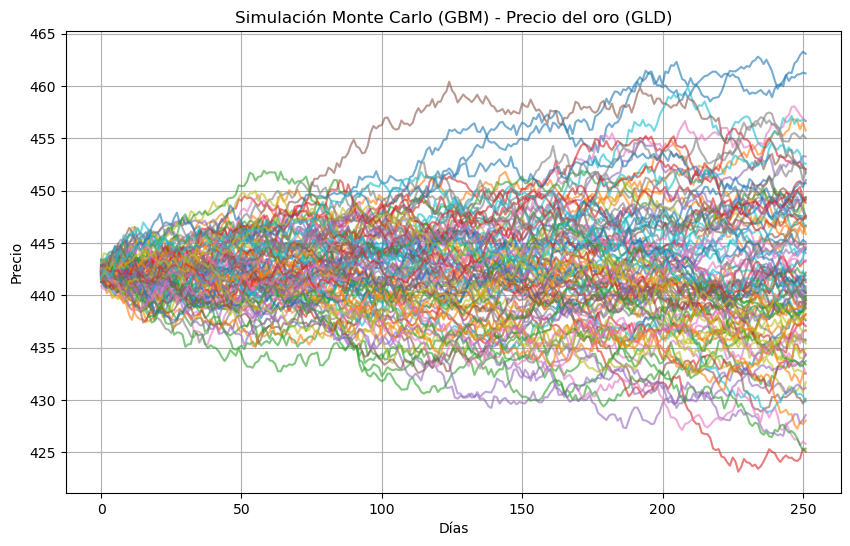

Precio actual: 442.17
Precio esperado (media): 441.87
Escenario pesimista (5%): 429.8
Escenario optimista (95%): 455.07


In [2]:
end_date = datetime.today()
start_date = end_date - timedelta(days=365)

ticker = "GLD"  # ETF del oro
data = yf.download(ticker, start=start_date, end=end_date)

# Si las columnas vienen como MultiIndex, simplificarlas
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


# Calcular retornos logarítmicos

data['LogReturns'] = np.log(data['Close'] / data['Close'].shift(1))
returns = data['LogReturns'].dropna()

# Parámetros estadísticos
mu = returns.mean()
sigma = returns.std()


# Parámetros de simulación

num_simulations = 100
num_days = 252  # 1 año futuro
dt = 1/252

last_price = data['Close'].iloc[-1]


# Simulación Monte Carlo (GBM)

simulations = np.zeros((num_days, num_simulations))

for sim in range(num_simulations):
    prices = [last_price]
    for day in range(num_days):
        # shock aleatorio
        z = np.random.normal()
        
        # fórmula GBM
        price = prices[-1] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
        prices.append(price)
    
    simulations[:, sim] = prices[1:]


#Graficar

plt.figure(figsize=(10,6))
plt.plot(simulations, alpha=0.6)
plt.title("Simulación Monte Carlo (GBM) - Precio del oro (GLD)")
plt.xlabel("Días")
plt.ylabel("Precio")
plt.grid()
plt.show()


# Resultado final (estadísticas)

final_prices = simulations[-1]

print("Precio actual:", round(last_price, 2))
print("Precio esperado (media):", round(final_prices.mean(), 2))
print("Escenario pesimista (5%):", round(np.percentile(final_prices, 5), 2))
print("Escenario optimista (95%):", round(np.percentile(final_prices, 95), 2))

## Modelo Black–Scholes–Merton

El **modelo de Black–Scholes–Merton** es una fórmula matemática utilizada para calcular el **precio teórico de opciones financieras** (como calls y puts) sobre activos como acciones, índices o commodities (por ejemplo, el oro).

Fue desarrollado en los años 70 por Fischer Black, Myron Scholes y Robert C. Merton, y es uno de los pilares de las finanzas modernas.

### Idea básica

El modelo estima el valor de una opción en función de:

- **Precio actual del activo**
- **Precio de ejercicio (strike)**
- **Tiempo hasta el vencimiento**
- **Volatilidad del activo**
- **Tasa libre de riesgo**

### Supuesto clave

Asume que el precio del activo sigue un proceso aleatorio continuo con volatilidad constante (movimiento browniano geométrico).

### Usos principales

- Valuar opciones financieras
- Detectar oportunidades comparando precio teórico vs mercado
- Base para modelos más avanzados en finanzas cuantitativas

### Resumen

El modelo no predice el precio futuro del activo, sino que calcula un **precio justo actual** para derivados financieros bajo ciertas condiciones idealizadas.

C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\1681231031.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Precio actual (GLD): 442.17
Strike (K): 464.28
Volatilidad anual: 27.48%
Precio teórico Call: 48.56


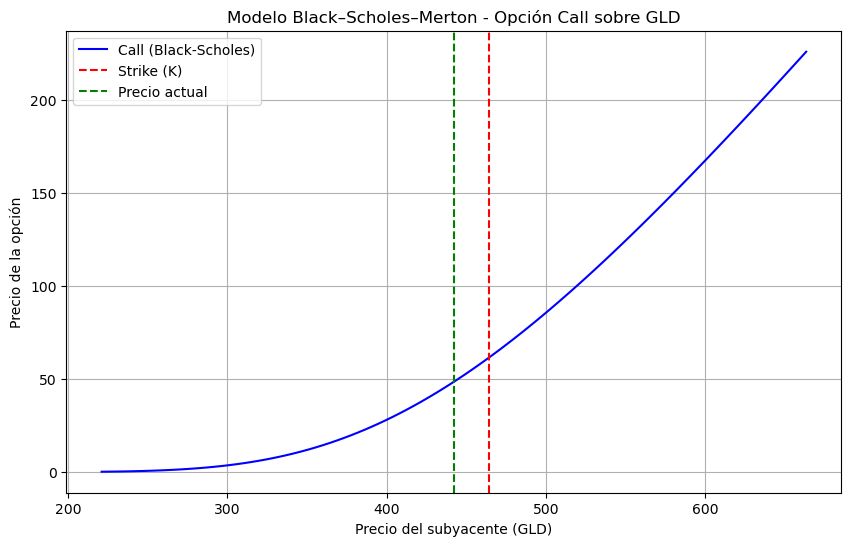

In [3]:
end_date = datetime.today()
start_date = end_date - timedelta(days=365)

ticker = "GLD"
data = yf.download(ticker, start=start_date, end=end_date)

# Arreglar MultiIndex si aparece
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


# Calcular volatilidad (log returns)

data['LogReturns'] = np.log(data['Close'] / data['Close'].shift(1))
returns = data['LogReturns'].dropna()

sigma = returns.std() * np.sqrt(252)  # volatilidad anual


# Parámetros del modelo

S = data['Close'].iloc[-1]  # precio actual
K = S * 1.05               # strike (5% arriba)
T = 1                      # 1 año
r = 0.05                   # tasa libre de riesgo (5%)


# 4. Black-Scholes-Merton

def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return call_price

call_price = black_scholes_call(S, K, T, r, sigma)


# Resultado

print(f"Precio actual (GLD): {S:.2f}")
print(f"Strike (K): {K:.2f}")
print(f"Volatilidad anual: {sigma:.2%}")
print(f"Precio teórico Call: {call_price:.2f}")

# Rango de precios del subyacente
S_range = np.linspace(S * 0.5, S * 1.5, 100)

# Precio de la opción para cada S
call_prices = [black_scholes_call(s, K, T, r, sigma) for s in S_range]

plt.figure(figsize=(10,6))
plt.plot(S_range, call_prices, label="Call (Black-Scholes)", color="blue")
plt.axvline(K, color="red", linestyle="--", label="Strike (K)")
plt.axvline(S, color="green", linestyle="--", label="Precio actual")

plt.title("Modelo Black–Scholes–Merton - Opción Call sobre GLD")
plt.xlabel("Precio del subyacente (GLD)")
plt.ylabel("Precio de la opción")
plt.grid()
plt.legend()
plt.show()

## Modelo Garch

El **modelo GARCH** es un modelo estadístico utilizado en finanzas para describir y predecir la **volatilidad de series temporales**, como precios de acciones, criptomonedas o materias primas.

---

### ¿Qué problema resuelve?

En los mercados financieros, la volatilidad no es constante:
- Hay períodos de calma
- Y períodos de alta turbulencia

El modelo GARCH permite capturar este comportamiento variable en el tiempo.

---

### Idea principal

La volatilidad actual depende de:
- los shocks pasados del mercado
- la volatilidad pasada

Esto genera el fenómeno conocido como **clustering de volatilidad** (la volatilidad tiende a agruparse).

---

### Modelo GARCH(1,1)

La forma más común es:

### Ecuación de retornos
$$
r_t = \mu + \epsilon_t
$$

$$
\epsilon_t = \sigma_t z_t
$$

donde:
- $r_t$: retorno del activo
- $\mu$: media
- $\epsilon_t$: shock aleatorio
- $z_t \sim N(0,1)$

---

### Ecuación de volatilidad

$$
\sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2
$$



### Interpretación de parámetros

- $\omega$ (omega): nivel base de volatilidad
- $\alpha$ (alpha): impacto de shocks recientes (noticias o eventos)
- $\beta$ (beta): persistencia de la volatilidad pasada
---

### Intuición

- Si el mercado tuvo un gran movimiento ayer → la volatilidad hoy aumenta
- Si la volatilidad fue alta recientemente → se mantiene alta
- Si no hay shocks → la volatilidad vuelve gradualmente a su nivel base

---

### ¿Por qué es importante?

El modelo GARCH se usa ampliamente en:
- Gestión de riesgo (VaR)
- Pricing de derivados financieros
- Modelado de incertidumbre en mercados
- Mejora de modelos como Black–Scholes

---

### Resumen

El modelo GARCH describe cómo:

> La volatilidad de un activo cambia en el tiempo dependiendo de los shocks y la volatilidad pasada.

C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\117835537.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


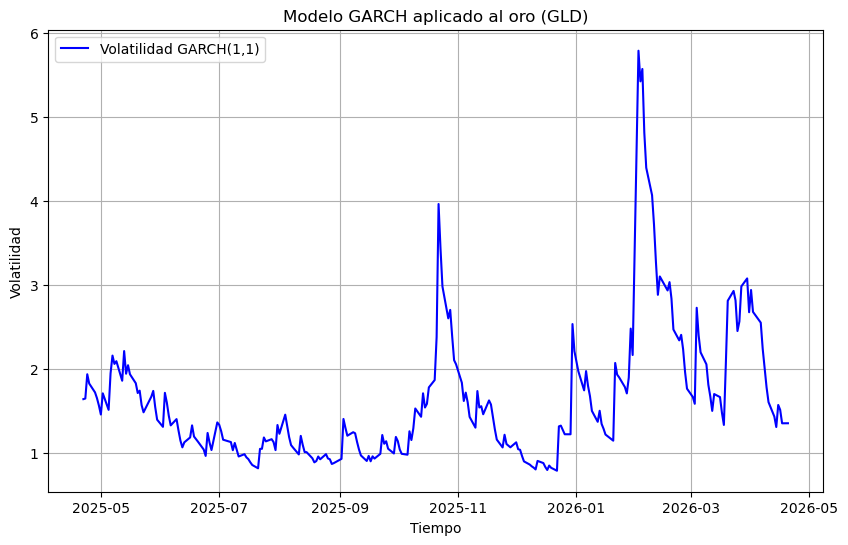

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -456.632
Distribution:                  Normal   AIC:                           921.264
Method:            Maximum Likelihood   BIC:                           935.350
                                        No. Observations:                  250
Date:                Mon, Apr 20 2026   Df Residuals:                      249
Time:                        17:12:44   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.1246  8.845e-02      1.409      0.159 [-4.87

In [4]:
end_date = datetime.today()
start_date = end_date - timedelta(days=365)

ticker = "GLD"
data = yf.download(ticker, start=start_date, end=end_date)

# Arreglar MultiIndex si aparece
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)


# Retornos logarítmicos

returns = 100 * np.log(data['Close'] / data['Close'].shift(1))
returns = returns.dropna()


# Modelo GARCH(1,1)

model = arch_model(returns, vol='Garch', p=1, q=1)
res = model.fit(disp="off")


# Volatilidad condicional

volatility = res.conditional_volatility


# Gráfico

plt.figure(figsize=(10,6))
plt.plot(volatility, label="Volatilidad GARCH(1,1)", color="blue")
plt.title("Modelo GARCH aplicado al oro (GLD)")
plt.xlabel("Tiempo")
plt.ylabel("Volatilidad")
plt.grid()
plt.legend()
plt.show()


# Resumen del modelo

print(res.summary())

## Modelo estocástico de Hull–White

El **modelo de Hull–White** es un modelo estocástico utilizado en finanzas cuantitativas para describir la evolución de las **tasas de interés en el tiempo**.

Es una extensión del modelo de Vasicek, pero con mayor flexibilidad porque permite que la media del proceso varíe con el tiempo.

---

### Idea principal

El modelo supone que la tasa de interés:

- Presenta reversión a la media
- Está sujeta a shocks aleatorios
- Puede adaptarse a cambios en la estructura de tasas del mercado

---

### Ecuación del modelo

La dinámica de la tasa corta \( r_t \) se define como:

$$
dr_t = (\theta(t) - a r_t)\,dt + \sigma\,dW_t
$$

---

### Interpretación de los parámetros

- $r_t$: tasa de interés en el tiempo $t$
- $a$: velocidad de reversión a la media
- $\theta(t)$: nivel medio dependiente del tiempo
- $\sigma$: volatilidad del proceso
- $dW_t$: movimiento browniano (ruido aleatorio)
---

### Intuición

- Cuando la tasa sube, el modelo tiende a empujarla hacia el promedio
- Cuando la tasa baja, también tiende a revertir
- La trayectoria es aleatoria, pero con tendencia de equilibrio

---

### Diferencias con otros modelos

- Vasicek: media constante
- Hull–White: media dependiente del tiempo, lo que permite ajustar mejor la curva de tasas observada en el mercado

---

### Aplicaciones

El modelo Hull–White se utiliza en:

- Valoración de bonos
- Pricing de derivados de tasas de interés
- Modelado de curvas de rendimiento
- Gestión de riesgo en renta fija

---

### Resumen

El modelo de Hull–White describe la evolución de las tasas de interés como un proceso estocástico con reversión a la media, donde el nivel medio puede variar en el tiempo.

C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\3311419499.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed


----- PARÁMETROS -----
Tasa actual (r0): 0.0425
Media (theta): 0.0353
Volatilidad (sigma): 0.0099
Mean reversion (a): 0.15


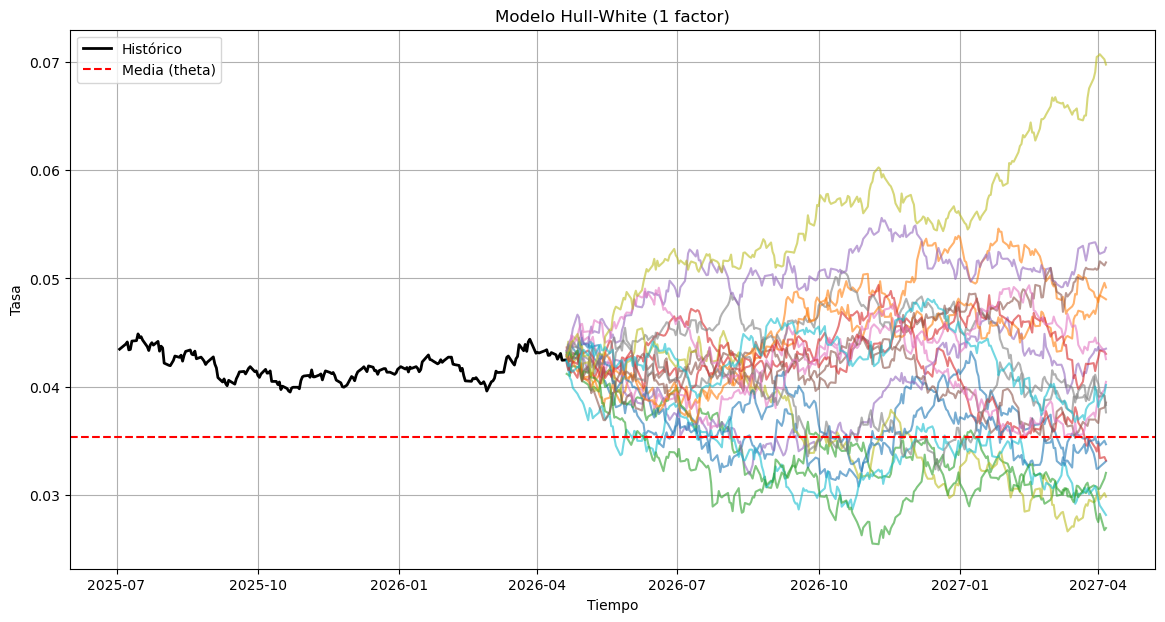

In [5]:
ticker = "^TNX"  # US 10Y Treasury (ejemplo)
data = yf.download(ticker, period="5y")


# LIMPIEZA ROBUSTA


# yfinance a veces devuelve MultiIndex
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# elegir columna correcta
if 'Adj Close' in data.columns:
    rates = data['Adj Close']
elif 'Close' in data.columns:
    rates = data['Close']
else:
    raise ValueError(f"No encuentro columna de precios en: {data.columns}")

rates = rates.dropna() / 100  # pasar a decimal


# PARÁMETROS


r0 = float(rates.iloc[-1])
theta = float(rates.mean())

returns = rates.diff().dropna()
sigma = float(returns.std() * np.sqrt(252))

a = 0.15

print("----- PARÁMETROS -----")
print(f"Tasa actual (r0): {r0:.4f}")
print(f"Media (theta): {theta:.4f}")
print(f"Volatilidad (sigma): {sigma:.4f}")
print(f"Mean reversion (a): {a}")


# SIMULACIÓN 


T = 1.0
dt = 1/252
N = int(T/dt)

n_sim = 20
simulations = np.zeros((N, n_sim))

for j in range(n_sim):
    r = r0
    path = []
    
    for i in range(N):
        dW = np.random.normal(0, np.sqrt(dt))
        
        # ✔️ fórmula correcta (Vasicek / HW simplificado)
        dr = a * (theta - r) * dt + sigma * dW
        
        r += dr
        path.append(r)
    
    simulations[:, j] = path



plt.figure(figsize=(14,7))

plt.plot(
    rates.index[-200:], 
    rates.values[-200:], 
    label="Histórico", 
    color="black", 
    linewidth=2
)

future_index = pd.date_range(
    start=rates.index[-1], 
    periods=N, 
    freq='B'
)

for j in range(n_sim):
    plt.plot(future_index, simulations[:, j], alpha=0.6)

plt.axhline(theta, linestyle="--", color="red", label="Media (theta)")

plt.title("Modelo Hull-White (1 factor)")
plt.xlabel("Tiempo")
plt.ylabel("Tasa")
plt.legend()
plt.grid()

plt.show()

C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\495114744.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), start="2022-01-01", progress=False)["Close"]


Curva actual:
3M     0.03850
5Y     0.03598
10Y    0.04250
30Y    0.04881
Name: 2026-04-20 00:00:00, dtype: float64

Sigma estimado: 0.0092

Precio del bono (teórico): 105.96


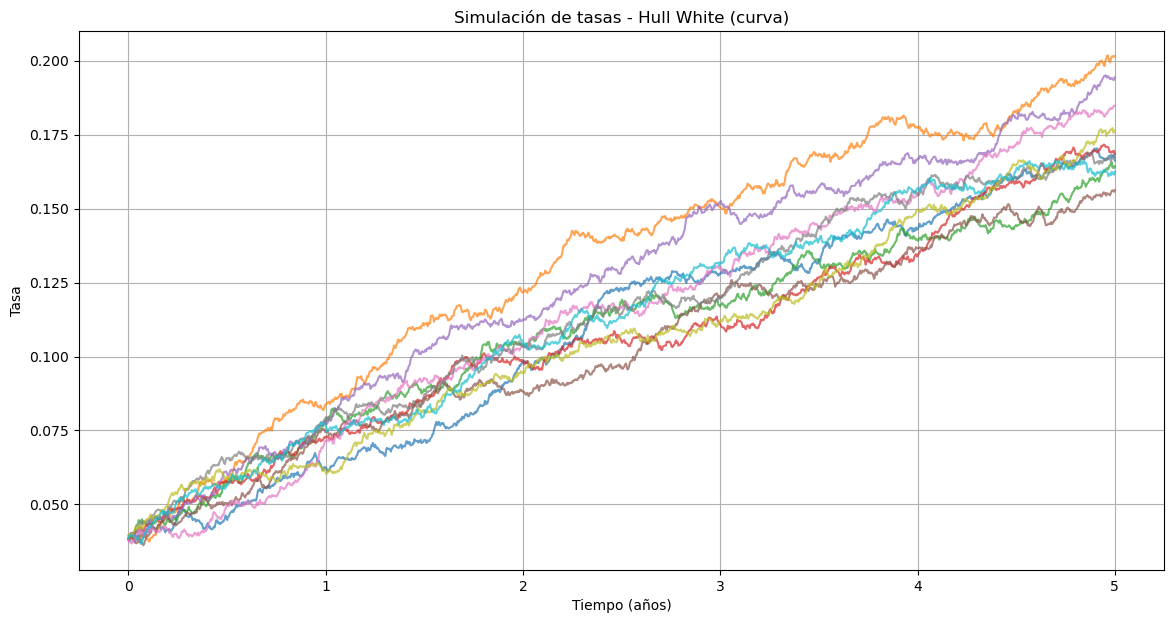

In [6]:
tickers = {
    "3M": "^IRX",   # 3 months
    "5Y": "^FVX",   # 5 years
    "10Y": "^TNX",  # 10 years
    "30Y": "^TYX"   # 30 years
}

data = yf.download(list(tickers.values()), start="2022-01-01", progress=False)["Close"]

# Limpiar datos
data = data.dropna()

# Normalizar a decimal
for col in data.columns:
    data[col] = data[col] / 100

# Renombrar columnas
data.columns = list(tickers.keys())

# Última curva (snapshot actual)
curve_today = data.iloc[-1]

print("Curva actual:")
print(curve_today)

# Construir curva simple (interpolación)

maturities = np.array([0.25, 5, 10, 30])  # años
rates_curve = curve_today.values

def yield_curve(t):
    return np.interp(t, maturities, rates_curve)


# Parámetros Hull-White

a = 0.1

# volatilidad promedio de la curva
returns = data.diff().dropna()
sigma = returns.std().mean() * np.sqrt(252)
sigma = float(sigma)

# theta aproximado = curva inicial
def theta(t):
    return yield_curve(t)

print(f"\nSigma estimado: {sigma:.4f}")


#  Simulación de curva (Monte Carlo)

T = 5
dt = 1/252
N = int(T/dt)

times = np.linspace(0, T, N)

n_sim = 10

simulated_rates = np.zeros((N, n_sim))

r0 = yield_curve(0.25)

for j in range(n_sim):
    r = r0
    path = []
    
    for i, t in enumerate(times):
        dW = np.random.normal(0, np.sqrt(dt))
        dr = (theta(t) - a * r) * dt + sigma * dW
        r += dr
        path.append(r)
    
    simulated_rates[:, j] = path


#  Pricing de bono cupón

def price_bond(face=100, coupon_rate=0.05, maturity=5, freq=1):
    cashflows = []
    times_cf = []
    
    for i in range(1, int(maturity*freq)+1):
        t = i / freq
        cf = face * coupon_rate / freq
        if i == maturity*freq:
            cf += face
        
        cashflows.append(cf)
        times_cf.append(t)
    
    # Discount con curva actual
    price = 0
    for cf, t in zip(cashflows, times_cf):
        r = yield_curve(t)
        df = np.exp(-r * t)
        price += cf * df
    
    return price

bond_price = price_bond()

print(f"\nPrecio del bono (teórico): {bond_price:.2f}")


# Graficar simulaciones

plt.figure(figsize=(14,7))

for j in range(n_sim):
    plt.plot(times, simulated_rates[:, j], alpha=0.7)

plt.title("Simulación de tasas - Hull White (curva)")
plt.xlabel("Tiempo (años)")
plt.ylabel("Tasa")
plt.grid()

plt.show()

## Deep Reinforcement Learning

El **Deep Reinforcement Learning (DRL)** es un área de la inteligencia artificial que combina dos campos fundamentales:

- Reinforcement Learning (aprendizaje por refuerzo)  
- Deep Learning (aprendizaje profundo)

El objetivo del DRL es entrenar agentes capaces de **tomar decisiones óptimas en entornos complejos**, aprendiendo directamente de la interacción con el entorno, sin necesidad de reglas explícitas.



#### Idea central

Un agente aprende mediante prueba y error:

1. Observa el estado del entorno  
2. Ejecuta una acción  
3. Recibe una recompensa  
4. Ajusta su estrategia para maximizar recompensas futuras  

Este proceso se formaliza mediante un **Markov Decision Process (MDP)**.



#### ¿Por qué "Deep"?

En el aprendizaje por refuerzo clásico, las decisiones se basaban en tablas o modelos simples.  
DRL introduce redes neuronales profundas para:

- Aproximar funciones de valor  
- Representar políticas complejas  
- Manejar espacios de estados de alta dimensión  

Esto permite resolver problemas donde el estado es muy grande o continuo (por ejemplo, imágenes o mercados financieros).



#### Ejemplo icónico

Uno de los hitos más conocidos es AlphaGo, desarrollado por DeepMind, que logró vencer a campeones humanos en el juego Go utilizando DRL.

#### Componentes clave

- Agente: quien toma decisiones  
- Entorno: el sistema con el que interactúa  
- Política (π): estrategia del agente  
- Recompensa (R): señal de aprendizaje  
- Función de valor (V/Q): mide qué tan buena es una acción o estado  



#### Aplicaciones

El DRL se utiliza en múltiples áreas:

- Videojuegos (control autónomo de agentes)  
- Vehículos autónomos  
- Finanzas (trading algorítmico, gestión de portafolios)  
- Robótica  
- Optimización de sistemas complejos  


#### Desafíos

A pesar de su potencia, el DRL presenta dificultades:

- Alto costo computacional  
- Inestabilidad en el entrenamiento  
- Necesidad de grandes volúmenes de datos/interacción  
- Dificultad para interpretar modelos  



#### Conclusión

El Deep Reinforcement Learning representa un avance clave en la inteligencia artificial, permitiendo que los sistemas aprendan comportamientos complejos en entornos dinámicos.  

Su capacidad para combinar percepción (Deep Learning) y decisión (Reinforcement Learning) lo convierte en una de las herramientas más poderosas para resolver problemas del mundo real.

---

C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\1508425014.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2020-01-01", progress=False)
C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\1508425014.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  state = int(env.reset())
C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\1508425014.py:75: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(next_state)
C:\Users\Lupin III\AppData\Local\Temp\ipykernel_8940\1508425014.py:78: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is de

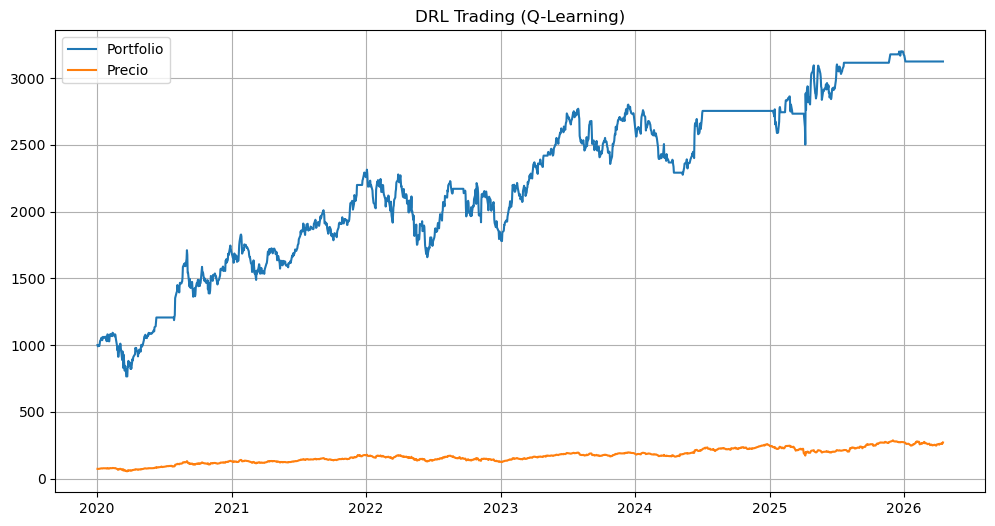

In [7]:
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", progress=False)

prices = data["Close"].dropna()


# Crear entorno simple

class TradingEnv:
    def __init__(self, prices):
        self.prices = prices.values
        self.n = len(prices)
        self.reset()

    def reset(self):
        self.t = 0
        self.position = 0  # 0: sin posición, 1: comprado
        self.cash = 1000
        self.shares = 0
        return self._get_state()

    def _get_state(self):
        return self.prices[self.t]

    def step(self, action):
        price = self.prices[self.t]

        # acciones: 0 = hold, 1 = buy, 2 = sell
        if action == 1 and self.position == 0:
            self.shares = self.cash / price
            self.cash = 0
            self.position = 1

        elif action == 2 and self.position == 1:
            self.cash = self.shares * price
            self.shares = 0
            self.position = 0

        self.t += 1

        done = self.t >= self.n - 1

        total_value = self.cash + self.shares * price
        reward = total_value

        return self._get_state(), reward, done


#  Q-Learning (simplificado)
n_actions = 3
q_table = {}

def get_q(state):
    return q_table.setdefault(state, np.zeros(n_actions))

alpha = 0.1
gamma = 0.95
epsilon = 0.1

env = TradingEnv(prices)

episodes = 50

for ep in range(episodes):
    state = int(env.reset())
    done = False

    while not done:
        if np.random.rand() < epsilon:
            action = np.random.choice(n_actions)
        else:
            action = np.argmax(get_q(state))

        next_state, reward, done = env.step(action)
        next_state = int(next_state)

        q = get_q(state)
        q[action] += alpha * (reward + gamma * np.max(get_q(next_state)) - q[action])

        state = next_state


# Evaluación

env = TradingEnv(prices)
state = int(env.reset())

values = []

done = False
while not done:
    action = np.argmax(get_q(state))
    next_state, reward, done = env.step(action)
    state = int(next_state)
    values.append(reward)


plt.figure(figsize=(12,6))

plt.plot(prices.index[:len(values)], values, label="Portfolio")
plt.plot(prices.index[:len(values)], prices.values[:len(values)], label="Precio")

plt.title("DRL Trading (Q-Learning)")
plt.legend()
plt.grid()

plt.show()